In [18]:
import os
from pathlib import Path
import torch
from forge_net.utils.common import *
from forge_net.utils.math import *
# from forge_net.utils.plotting import * 
from forge_net.invert_deltas import invert_deltas_to_mesh, save_comparison_turntable
# from forge_net.loss.chamfer import chamfer_distance
from pytorch3d.loss import chamfer_distance #original implementation uses a chamfer distance
from tqdm import tqdm 
import matplotlib.pyplot as plt

#Evaluate an existing trained model
from forge_net.model.trainer import ForgeNetTrainer
import yaml


def compare_scatters(pc1, pc2, label_1=None, label_2=None, label_3=None, fig_path=None):
    view_angle = (90, -90, 0) # XZ view
    fig = plt.figure(figsize=(20,6))
    
    ax1 = fig.add_subplot(131, projection = '3d')
    ax1.scatter(xs=pc1[:,0],ys=pc1[:,1],zs=pc1[:,2], s=3.5, color='blueviolet')
    ax1.set_title(label_1)
    ax1.set_axis_off()
    ax1.view_init(elev=view_angle[0], azim=view_angle[1], roll=view_angle[2])
    
    ax2 = fig.add_subplot(132, projection = '3d')
    ax2.scatter(xs=pc2[:,0],ys=pc2[:,1],zs=pc2[:,2], s=3.5, color='red')
    ax2.set_title(label_2)
    ax2.set_axis_off()
    ax2.view_init(elev=view_angle[0], azim=view_angle[1], roll=view_angle[2])
    
    ax3 = fig.add_subplot(133, projection = '3d')
    ax3.scatter(xs=pc1[:,0],ys=pc1[:,1],zs=pc1[:,2], s=3.0, color='blueviolet')
    ax3.scatter(xs=pc2[:,0],ys=pc2[:,1],zs=pc2[:,2], s=3.0, color='red')
    ax3.set_title(label_3)
    # ax3.set_axis_off()
    x_range = pc1[:,0].max() - pc1[:,0].min()
    y_range = pc1[:,1].max() - pc1[:,1].min()
    z_range = pc1[:,2].max() - pc1[:,2].min()
    ax3.view_init(elev=view_angle[0], azim=view_angle[1], roll=view_angle[2])
    for ax in [ax1, ax2, ax3]:
            ax.set_box_aspect((x_range, y_range, z_range))
    plt.subplots_adjust(wspace=-0.1)
    if fig_path is not None:
        plt.savefig(fig_path)
    else:
        plt.show()


def evaluate(config, trainer):
    '''
    Evaluate a trained ForgeNet network by creating some simple scatter and vector plots
    
    :param config: YAML config containing paths to data and network settings
    :param trainer: trainer class instance
    '''
    data_path = config["datasets"]["data_out"]
    assert os.path.exists(data_path), "Dataset found"
    data  = np.load(data_path)
    states = data['coords_t']
    states_tp1 = data['coords_tp1']
    action_features = config["network"]["action_features"]
    
    actions = actions_from_feature_map(action_features, data)
    
    output_folder = Path(config["run"]["run_folder"])
    eval_path = output_folder / "eval"
    eval_path.mkdir(exist_ok=True)

    trainer.load(model_path = output_folder / "best_model.pth")
    
    def forward(x,a):
        with torch.no_grad():
            return(trainer.net(x_t=x,a_t=a))
    
    for idx in config["eval"]["eval_idxs"]:
        idx = 0
        idx_path = eval_path / str(idx)
        idx_path.mkdir(exist_ok=True)

        x_t = torch.tensor(states[idx], dtype=torch.float32).T.unsqueeze(0).to(trainer.device) # x.shape = 1,3,n_points   
        x_tp1 = torch.tensor(states_tp1[idx], dtype=torch.float32).T.unsqueeze(0).to(trainer.device) # x.shape = 1,3,n_points

        a = torch.tensor(actions[idx], dtype=torch.float32).unsqueeze(0).to(trainer.device) #a.shape = 1,8
        x_t_np = x_t.T.squeeze().cpu().numpy()
        x_tp1_np = x_tp1.T.squeeze().cpu().numpy()
        delta_hat = forward(x_t,a) / 100
        x_tp1_hat = x_t.squeeze(0).T + delta_hat.squeeze(0)
        x_tp1_hat = x_tp1_hat.cpu().numpy()
        delta_hat = delta_hat.cpu().squeeze().T
        delta_gt = (x_tp1 - x_t).squeeze().cpu()    

        if config["network"]["loss"] == "mse": #TODO - these should be x_t and x_tp1
            loss_cont = torch.sum(((delta_hat - delta_gt) ** 2),axis=0).squeeze(0).numpy()
        
        elif config["network"]["loss"] == "chamfer" or config["network"]["loss"] == "wsd":
            loss_cont =  chamfer_distance(delta_gt.T.unsqueeze(0), 
                                          delta_hat.T.unsqueeze(0), 
                                          point_reduction=None, 
                                          batch_reduction=None)[0][0][-1]
        
        else:
            raise ValueError("Loss function not found")

        #Make eval plots
        compare_scatters(pc1=x_tp1_np, pc2=x_tp1_hat, 
                    label_1="Ground Truth Mesh Tp1", 
                    label_2="Predicted Mesh Tp1", 
                    label_3='G.T. vs. Predicted',
                    fig_path= None)


Initializing model with point_size=2048, latent_size=512
Using single GPU
Total parameters: 806,275
Trainable parameters: 806,275
Using MSE loss function


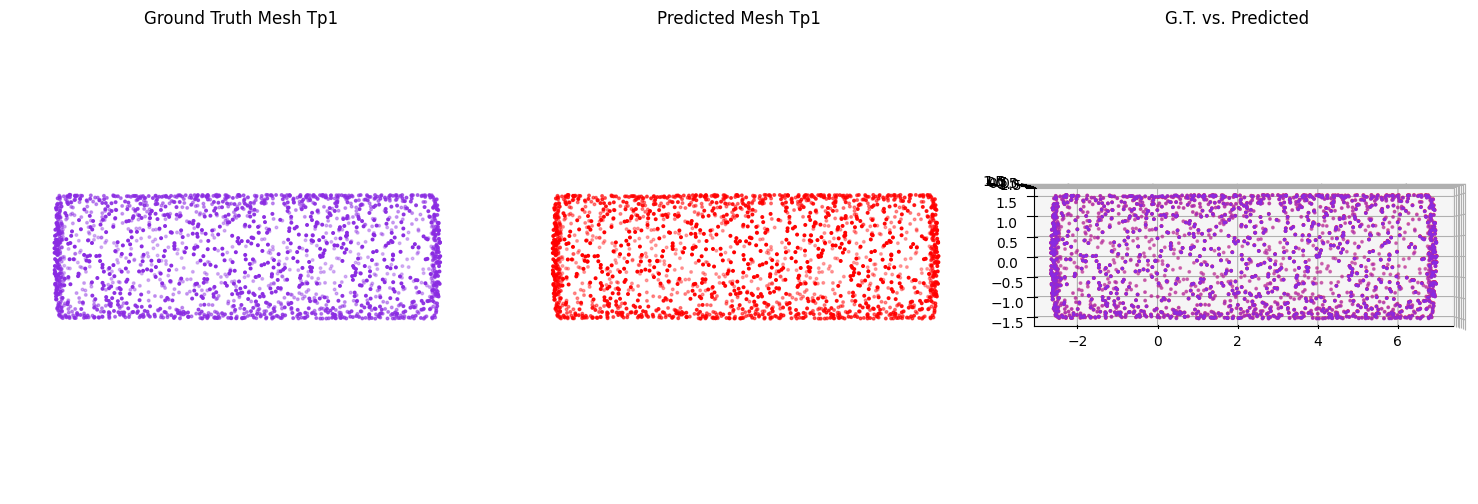

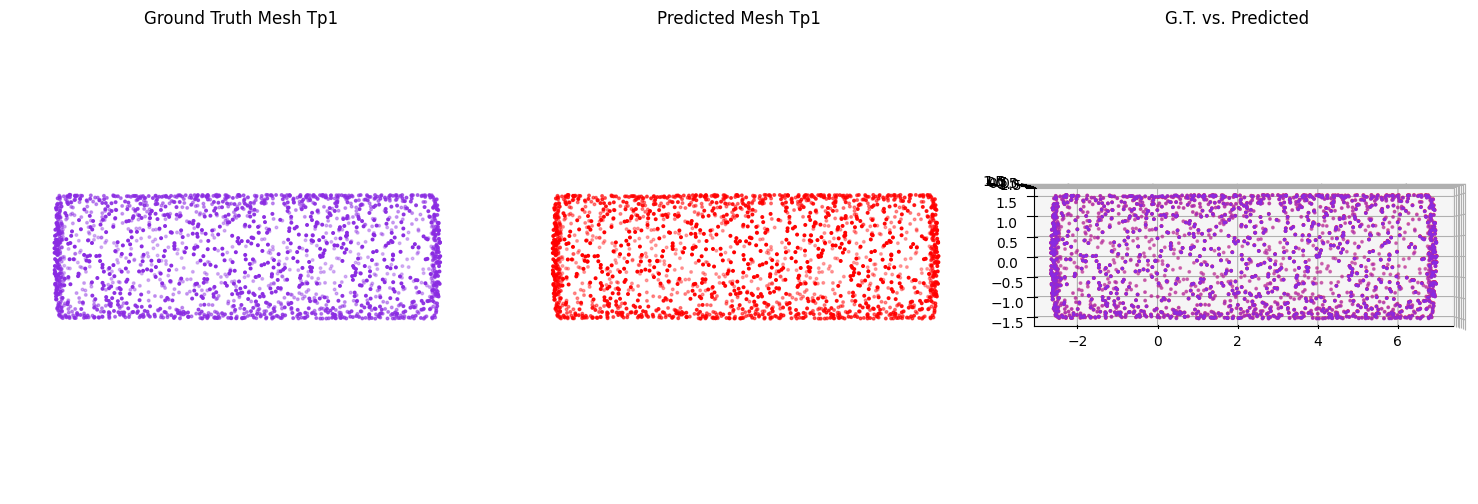

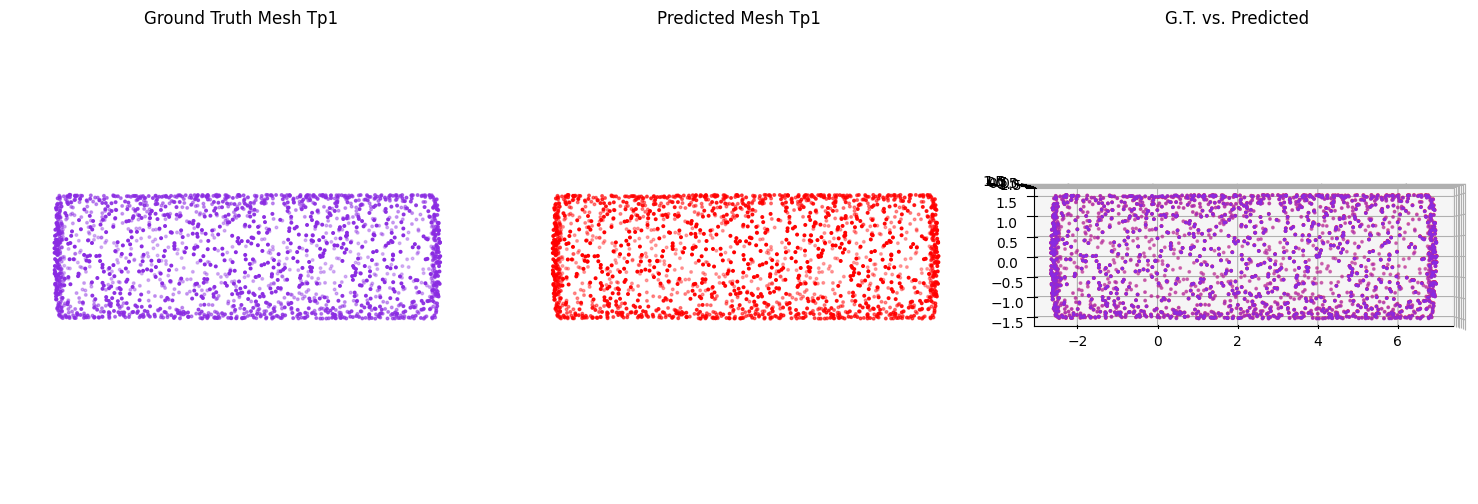

In [19]:
base_path = get_project_root()
run_name = "mse_2048_unmasked"
config_path = base_path / "runs" / run_name / "config_out.yml"
with open(config_path, 'r') as file:
    config = yaml.safe_load(file)
from forge_net.main import make_dataloaders
train_loader, test_loader = make_dataloaders(config)
trainer = ForgeNetTrainer(config, train_loader, log_to_tb=False)
output_folder = Path(config["run"]["run_folder"])
eval_path = output_folder / "eval"
eval_path.mkdir(exist_ok=True)

trainer.load(model_path = output_folder / "best_model.pth")
trainer.net.eval()
evaluate(config, trainer)